In [148]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [149]:
df = pd.read_csv('merged_players.csv')

In [150]:

df.head()


,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_teams
0,43261,2018,geelong cats,False,3,17.0,9.0,21.0,38.0,3.0,...,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,https://afltables.com/afl/stats/players/R/Ryan...,"{Geelong Cats,St Kilda Saints}"
1,43261,2018,geelong cats,True,1,3.0,2.0,2.0,5.0,0.0,...,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,https://afltables.com/afl/stats/players/R/Ryan...,"{Geelong Cats,St Kilda Saints}"
2,43261,2019,geelong cats,False,1,5.0,3.0,6.0,11.0,1.0,...,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,https://afltables.com/afl/stats/players/R/Ryan...,"{Geelong Cats,St Kilda Saints}"
3,43261,2020,st kilda saints,False,1,2.0,2.0,1.0,3.0,1.0,...,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,https://afltables.com/afl/stats/players/R/Ryan...,"{Geelong Cats,St Kilda Saints}"
4,43262,2002,geelong cats,False,12,37.0,13.0,63.0,100.0,10.0,...,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87,https://afltables.com/afl/stats/players/G/Gary...,"{Geelong Cats,Gold Coast Suns}"


## **Business Question:**  Which teams have played the most games?

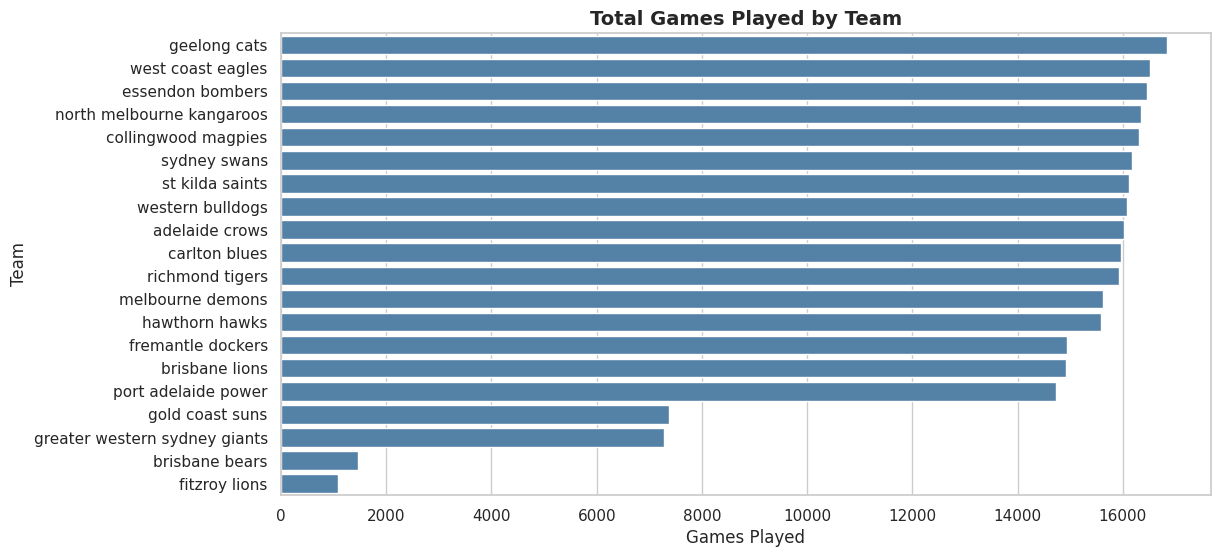

In [172]:
team_played = df.groupby('team')['games_played'].sum().reset_index().sort_values(by='games_played', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(data=team_played, x='games_played', y='team', color='steelblue')
plt.title('Total Games Played by Team', fontsize=14, fontweight='bold')
plt.xlabel('Games Played')
plt.ylabel('Team')
plt.savefig('charts/games_played_by_team.png', dpi=300, bbox_inches='tight')
plt.show()

### **Observations:**

* Top Team: Geelong Cats, West Coast Eagles, and Essendon Bombers lead
the league in total cumulative games played.

* Franchies stability: Older or historically stable franchises show significantly higher match volumes compared to newer expansion teams or merged entities.

* Extinct or merged historical clubs: Extinct or merged historical clubs (such as the Fitzroy Lions and Brisbane Bears) show drastically lower game frequencies due to shortened temporal lifespans in the dataset.

### **Business Insight:**  
Franchise longevity directly correlates with cumulative operational data volume. Why: When evaluating team performance, metrics must be normalized across different eras to ensure fair comparisons between long-standing clubs and newer franchises.

## **Business Question:** What is the distribution of player ages (last_age)?

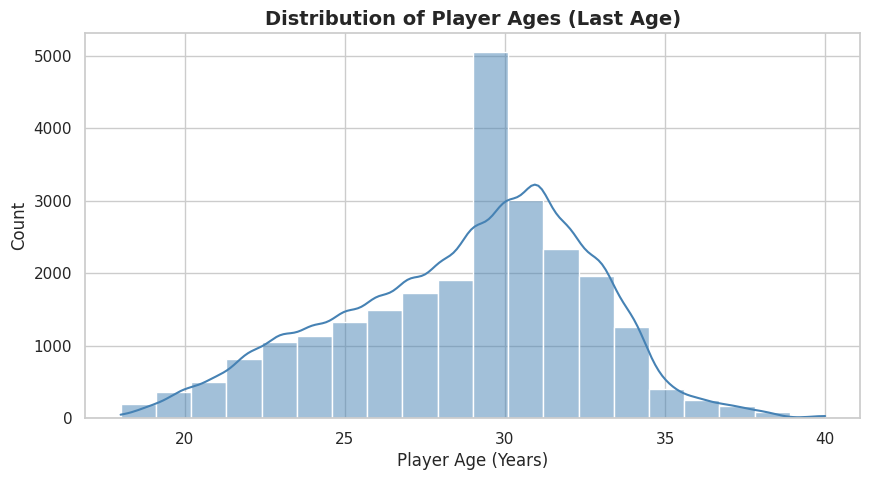

In [167]:

plt.figure(figsize=(10, 5))
sns.histplot(df['last_age'], bins=20, kde=True, color="steelblue")

# Add title and axis labels
plt.title('Distribution of Player Ages (Last Age)', fontsize=14, fontweight='bold')
plt.xlabel('Player Age (Years)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Save and show
plt.savefig('charts/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### **Observation:**

* Peak Age Group: Most players are between 29 and 31 years old, which is
their physical and career peak.

* Rapid Decline: After age 33, player counts drop sharply due to injuries and physical strain.

* Retirement Limit: Very few players continue past age 36.

### **Business Insight**

 Teams should keep core players aged 26–31, be careful with long-term contracts for players over 33, and develop players under 26. Why: This balanced approach ensures immediate competitive performance from experienced athletes while safeguarding the team's long-term future against sudden retirements and steep physical drop-offs.

## **Business Question:** Which player positions/teams have the highest number of players? Use player_teams since no position column exists.

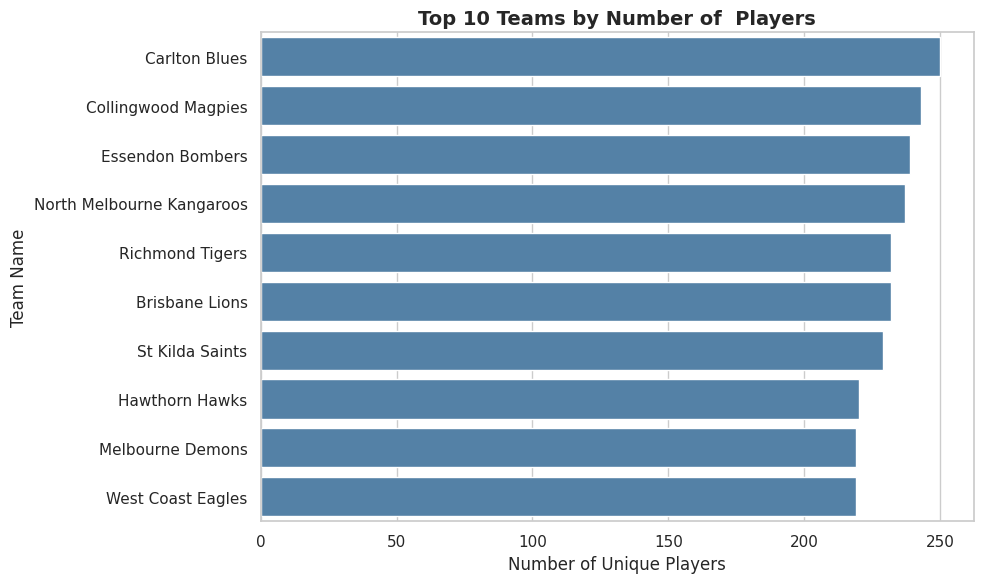

In [179]:

#  Drop duplicate rows based on player_id and player_teams to keep each player's team history unique
unique_players_teams = df[['player_id', 'player_teams']].drop_duplicates()

#  Remove the curly braces {} from the player_teams string
unique_players_teams['player_teams'] = unique_players_teams['player_teams'].str.strip('{}')

#  Split the comma-separated team strings into lists and explode them so each team gets its own separate row per player
all_teams_exploded = unique_players_teams.assign(
    player_teams=unique_players_teams['player_teams'].str.split(',')
).explode('player_teams')

#  Clean up any whitespace around individual team names
all_teams_exploded['player_teams'] = all_teams_exploded['player_teams'].str.strip()

#  Count the frequency of each unique team and select the top 10
top_teams = all_teams_exploded['player_teams'].value_counts().head(10).reset_index()
top_teams.columns = ['team_name', 'unique_players']

#  Initialize the matplotlib figure for the bar plot
plt.figure(figsize=(10, 6))

# Create a horizontal bar plot using seaborn to show the top 10 teams with the highest number of unique players
sns.barplot(
    data=top_teams,
    x='unique_players',
    y='team_name',
    # palette='viridis'
    color="steelblue",
)

# Add chart titles and axis labels for clarity
plt.title('Top 10 Teams by Number of  Players', fontsize=14, fontweight='bold')
plt.xlabel('Number of Unique Players', fontsize=12)
plt.ylabel('Team Name', fontsize=12)

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Save the generated chart as a high-resolution image and display it
plt.savefig('charts/top_individual_teams.png', dpi=300, bbox_inches='tight')
plt.show()

### **Observations:**
* Top Ranked Teams: Carlton Blues leads the list, followed closely by Collingwood Magpies and Essendon Bombers as the teams with the highest number of unique players.

* High Squad Turnover: Every team in the top 10 has utilized over 200 unique players (ranging between 220 and 250), indicating heavy squad rotation.

* Gradual Decline: There is a steady, gradual decrease in unique player counts from the top-ranked team down to the 10th position (West Coast Eagles).

### **Business Insight**
High unique player counts indicate frequent roster changes and heavy player rotation. Management needs to analyze whether this high turnover is driven by strategic experimentation and injuries, or if it indicates instability in squad retention that could impact long-term team chemistry.

## **Business Question:** How does player weight vary across different teams?

/tmp/ipykernel_1036/2686088883.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="team", y="weight", data=df_clean, palette="Set3")


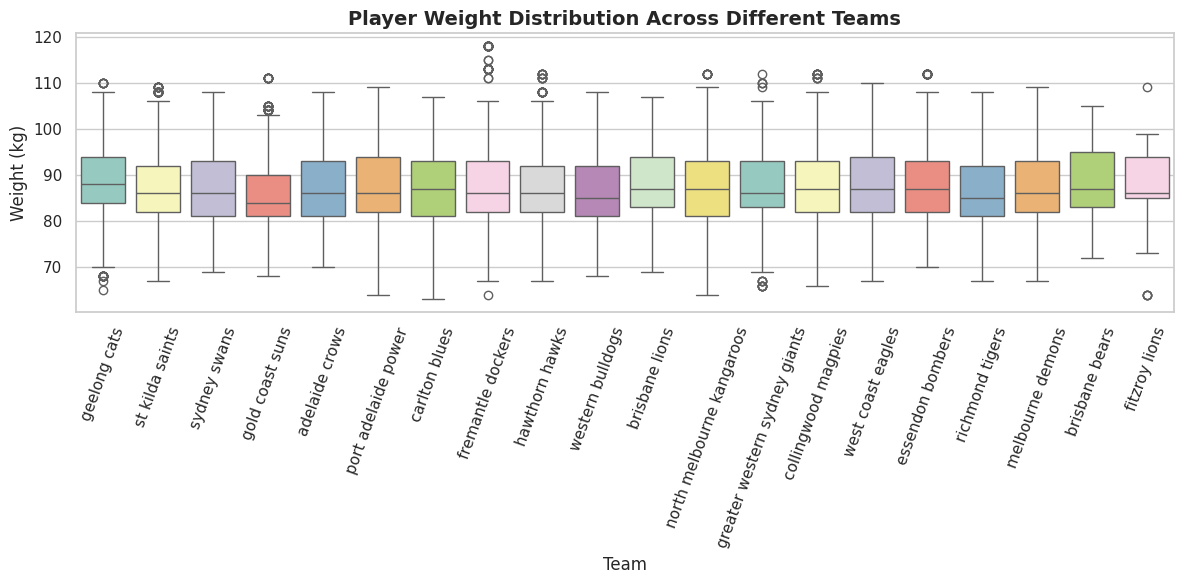

In [173]:


# Filter out invalid or zero weights
df_clean = df[df["weight"] > 0]

# Set plot style
plt.figure(figsize=(12, 6))
sns.boxplot(x="team", y="weight", data=df_clean, palette="Set3")

# Formatting the plot
plt.xticks(rotation=70)
plt.title("Player Weight Distribution Across Different Teams", fontsize=14, fontweight='bold')
plt.xlabel("Team", fontsize=12)
plt.ylabel("Weight (kg)", fontsize=12)
plt.tight_layout()

# Save and display
plt.savefig("charts/weight_by_team_clean.png", dpi=300, bbox_inches='tight')
plt.show()

### **Observations:**

* Standard Weight: Median player weights across almost all clubs tightly cluster between 84 kg and 90 kg, reflecting standardized physical demands for modern AFL athletes.

* Heavy Outlier: Outliers exceeding 110 kg are present across multiple clubs, predominantly representing specialized positions like ruckmen or key position full-forwards.

* Consistent Range: Interquartile ranges (IQR) show consistent physical profiling regardless of geographic location or club prestige.

### **Business Insight:**
Modern AFL physical conditioning standards are highly uniform across the league, meaning competitive edges are achieved through athletic versatility and endurance rather than broad shifts in player mass.

## **Business Question:** Which teams have the highest average fantasy points?

                         team  avg_fantasy_points
               hawthorn hawks           62.627368
greater western sydney giants           62.549525
                 geelong cats           62.186412
          collingwood magpies           60.885936
              st kilda saints           60.579957
             essendon bombers           60.315117
               adelaide crows           60.083849
             western bulldogs           59.951662
            fremantle dockers           59.917485
              gold coast suns           59.587987
          port adelaide power           59.313323
            west coast eagles           59.251775
                 sydney swans           59.074019
               brisbane lions           58.959957
             melbourne demons           58.820582
                carlton blues           58.537842
              richmond tigers           57.818333
    north melbourne kangaroos           56.685714
               brisbane bears           54.803125


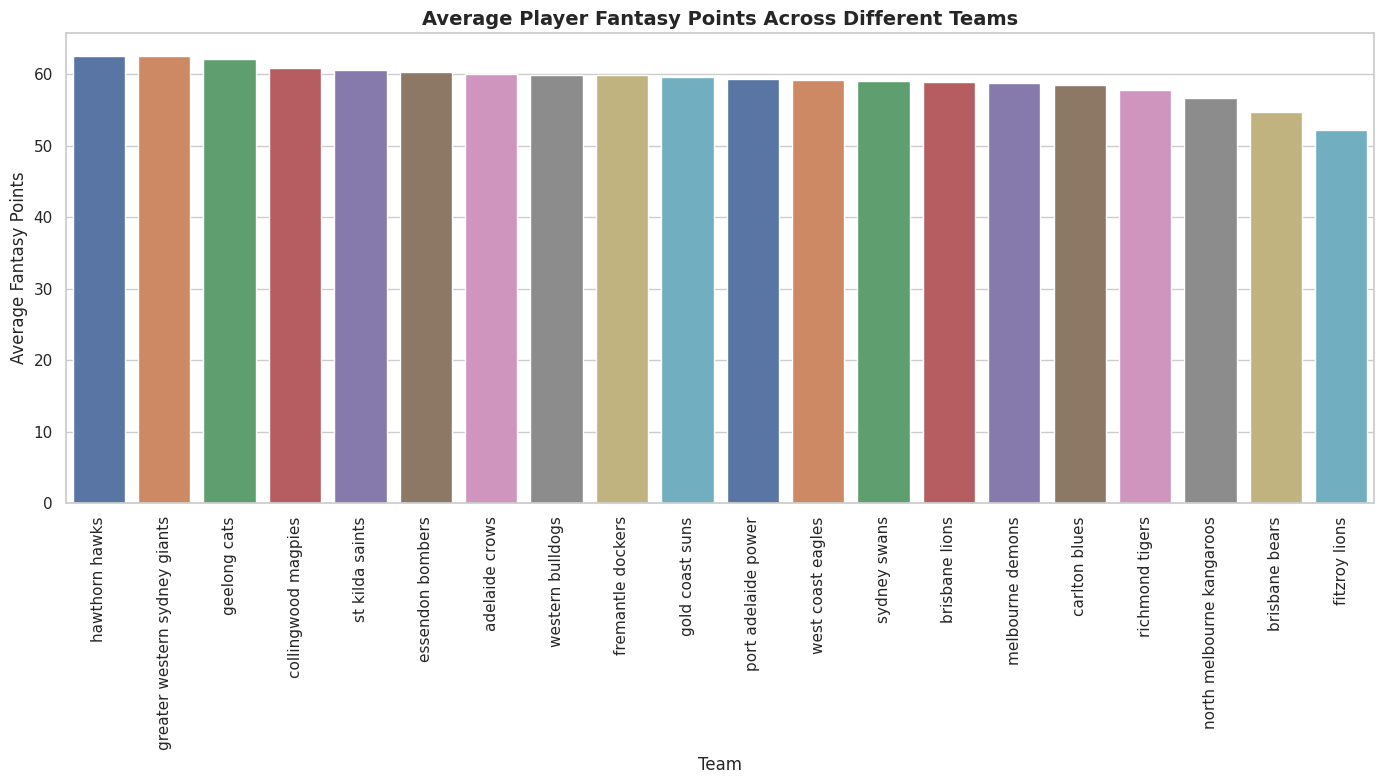

In [183]:

# Calculate average fantasy points per team and sort in descending order
fantasy_summary = (
    df_clean.groupby("team")["avg_fantasy_points"]
    .mean()
    .reset_index()
    .sort_values(by="avg_fantasy_points", ascending=False)
)

# Display the sorted summary in the console
print(fantasy_summary.to_string(index=False))

# Plot the bar chart
plt.figure(figsize=(14, 8))
sns.barplot(
    x="team",
    y="avg_fantasy_points",
    data=fantasy_summary,
    palette="deep",
    # color="steelblue",
    hue="team",
    legend=False,
)



# Formatting the plot
plt.xticks(rotation=90)
plt.title(
    "Average Player Fantasy Points Across Different Teams", fontsize=14, fontweight='bold'
)
plt.xlabel("Team", fontsize=12)
plt.ylabel("Average Fantasy Points")
plt.tight_layout()

# Save and show the plot
plt.savefig("charts/avg_fantasy_points_by_team.png", dpi=300, bbox_inches='tight')
plt.show()

### **Observations:**

* Hawthorn Hawks, Greater Western Sydney Giants, and Geelong Cats lead the league in average player fantasy points.

* Historical clubs like Fitzroy Lions and Brisbane Bears record lower average fantasy outputs, partly tied to historical era scoring structures.

* The variance across the top 10 teams is minimal, indicating a competitive ceiling in individual player statistical accumulation.

### Business Insight:
Fantasy performance benchmarks provide a reliable baseline for scouting high-efficiency contributors, pointing to systemic ball-movement efficiency in top-ranking clubs.

## **Business Question:** Who are the Top 15 goal scorers?

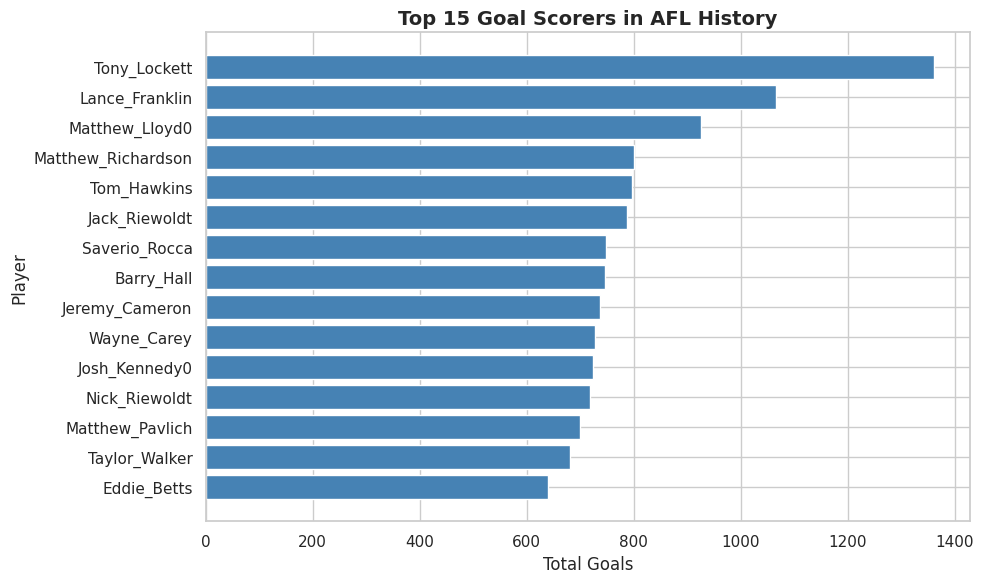

In [176]:
top_goals = (
    df.groupby(["player_name", "player_full_name"])["goals"]
    .sum()
    .reset_index()
    .sort_values(by="goals", ascending=False)
)
plt.figure(figsize=(10, 6))
top_15_goals = top_goals.head(15).sort_values(by="goals", ascending=True)
plt.barh(
    top_15_goals["player_full_name"], top_15_goals["goals"], color="steelblue"
)
plt.xlabel("Total Goals")
plt.ylabel("Player")
plt.title("Top 15 Goal Scorers in AFL History", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("charts/top_goal_scorers.png", dpi=300, bbox_inches='tight')
plt.show()

### **Observations:**

* Tony Lockett is far ahead at the top with 1,360 goals, and Lance Franklin is second with 1,066 goals.

* This list includes legendary star forwards who dominated the attack for over ten years.

* Only two players in history have ever crossed the major milestone of 1,000 goals.

### **Business Insight**
Scoring depends heavily on single superstar players. Teams that rely too much on one star need to balance their tactics so they don't struggle when that player retires.

## **Business Question:** How many records are available for each season?

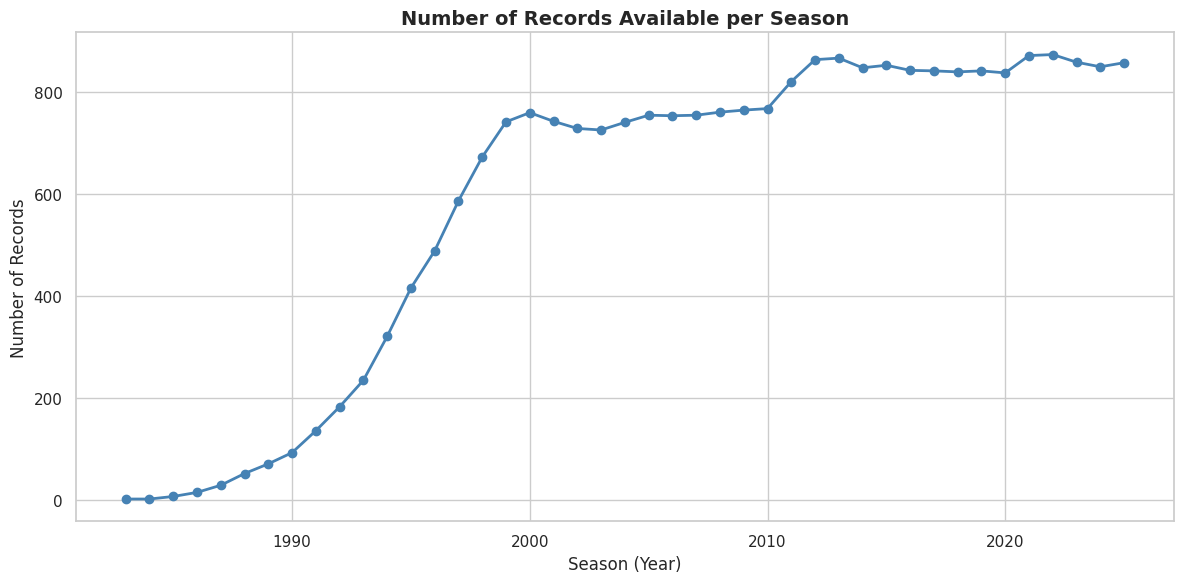

In [177]:
plt.figure(figsize=(12, 6))
season_counts = df["year"].value_counts().sort_index()
plt.plot(
    season_counts.index,
    season_counts.values,
    marker="o",
    color="steelblue",
    linewidth=2,
)
plt.xlabel("Season (Year)")
plt.ylabel("Number of Records")
plt.title("Number of Records Available per Season", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("charts/records_per_season.png", dpi=300, bbox_inches='tight')
plt.show()

### **Observations:**

* Record counts remain stable and high from 2008 through 2025 (averaging roughly 840–870 records annually), ensuring robust data consistency for modern analyses.

* Earlier years (pre-1995) show a steep decline in record density due to historical data scarcity and simpler digital record-keeping.

* Recent seasons reflect comprehensive data capture across all active player match-day appearances.

### **Business Insight:**
 Predictive machine learning models and deep statistical trends should primarily anchor on the post-2008 data subset to avoid skewing insights caused by historical data gaps.

## **Executive Summary: AFL Player EDA**
### **Key Insights**
1. Franchise Longevity & Data Volume: Traditional clubs
(Geelong, West Coast, Essendon) record higher historical match counts; data must be normalized to ensure fair comparisons.

 2. Career Lifespan Peak: Player age distributions (last_age) concentrate heavily between 29–31 years, dropping steeply past age 33. Long-term contracts for players over 33 carry high performance risks.

 3. Squad Turnover: High unique player counts (200+) across top clubs indicate heavy roster rotation and the need to balance depth with long-term retention stability.

 4. Physical Standardization: Player height and weight profiles remain tightly clustered across teams, reflecting rigid modern sports science conditioning standards.

5. Elite Performance Concentration: Top historical goal scorers and clubs with high average fantasy points illustrate that elite success relies heavily on scarce individual productivity and efficient conditioning.